In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [46]:
df = pd.read_csv("letter-recognition.data", header=None)

In [47]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [48]:
df.shape

(20000, 17)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       20000 non-null  object
 1   1       20000 non-null  int64 
 2   2       20000 non-null  int64 
 3   3       20000 non-null  int64 
 4   4       20000 non-null  int64 
 5   5       20000 non-null  int64 
 6   6       20000 non-null  int64 
 7   7       20000 non-null  int64 
 8   8       20000 non-null  int64 
 9   9       20000 non-null  int64 
 10  10      20000 non-null  int64 
 11  11      20000 non-null  int64 
 12  12      20000 non-null  int64 
 13  13      20000 non-null  int64 
 14  14      20000 non-null  int64 
 15  15      20000 non-null  int64 
 16  16      20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB


In [50]:
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

In [51]:
X.shape

(20000, 16)

In [52]:
y.shape

(20000,)

In [53]:
encoder = LabelEncoder()

In [54]:
y = encoder.fit_transform(y)

In [55]:
scaler = StandardScaler()

In [56]:
X = scaler.fit_transform(X)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
model = Sequential()

In [59]:
model.add(Dense(128, activation='relu', input_shape=(16,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

#output layer = 26 classes
model.add(Dense(26, activation='softmax'))

D:\DL\dl_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [61]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape  ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ dense_7 (Dense)     │ (None, 128)   │   2,176 │
├─────────────────────┼───────────────┼─────────┤
│ dense_8 (Dense)     │ (None, 64)    │   8,256 │
├─────────────────────┼───────────────┼─────────┤
│ dense_9 (Dense)     │ (None, 32)    │   2,080 │
├─────────────────────┼───────────────┼─────────┤
│ dense_10 (Dense)    │ (None, 26)    │     858 │
└─────────────────────┴───────────────┴─────────┘

 Total params: 13,370 (52.23 KB)

 Trainable params: 13,370 (52.23 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=30, batch_size=32, verbose=1)

Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5487 - loss: 1.6284 - val_accuracy: 0.7391 - val_loss: 0.9339
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7811 - loss: 0.7501 - val_accuracy: 0.8069 - val_loss: 0.6724
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8384 - loss: 0.5575 - val_accuracy: 0.8519 - val_loss: 0.5170
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8642 - loss: 0.4596 - val_accuracy: 0.8641 - val_loss: 0.4554
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8847 - loss: 0.3871 - val_accuracy: 0.8816 - val_loss: 0.3972
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9016 - loss: 0.3353 - val_accuracy: 0.8906 - val_loss: 0.3548
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9101 - loss: 0.2954 - val_accuracy: 0.8978 - val_loss: 0.3265
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9195 - loss: 0.2615 - val_accuracy: 0.

In [63]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [64]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.95225

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       149
           1       0.85      0.96      0.90       153
           2       0.98      0.93      0.95       137
           3       0.95      0.93      0.94       156
           4       0.93      1.00      0.97       141
           5       0.90      0.94      0.92       140
           6       0.97      0.96      0.97       160
           7       0.92      0.85      0.88       144
           8       0.97      0.94      0.95       146
           9       0.93      0.95      0.94       149
          10       0.90      0.91      0.90       130
          11       0.98      0.97      0.98       155
          12       0.99      0.98      0.99       168
          13       0.98      0.95      0.96       151
          14       0.94      0.93      0.94       145
          15       0.97      0.96      0.97       173
          16       0.96      0.95      0.95       166
          17       0.91    

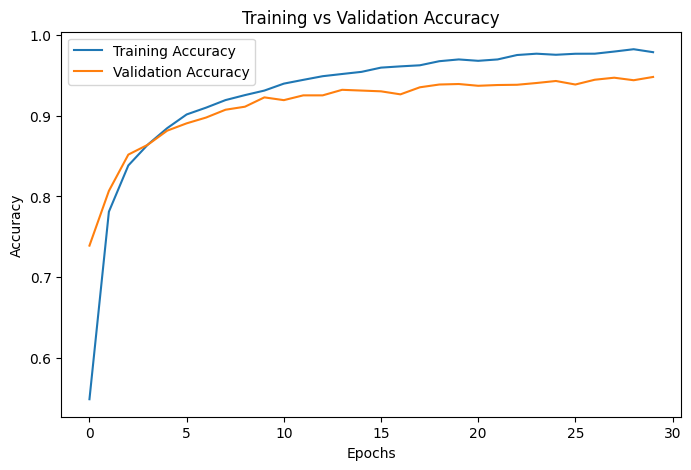

In [66]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()